<div style="background: linear-gradient(135deg, #f857a6 0%, #ff5858 100%); padding: 36px 40px; border-radius: 14px; color: white; font-family: 'Segoe UI', sans-serif; box-shadow: 0 8px 24px rgba(0,0,0,0.18); margin-bottom: 10px;">
<h1 style="margin:0; font-size: 30px; letter-spacing: -0.5px;">Customer Segmentation Engine</h1>
<p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.92;">Unsupervised K-Means + Hierarchical clustering on real Mall Customer data, with full interactive 3D analytics and business personas.</p>
<p style="margin: 14px 0 0 0; font-size: 13px; opacity: 0.75; font-family: 'Courier New', monospace;">Progree Data Science Internship &nbsp;|&nbsp; Built end-to-end in Python</p>
</div>

**Task 3 — Unsupervised Machine Learning Customer Segmentation (Clustering)**

| | |
|---|---|
| **Dataset** | Mall Customer Segmentation Data (Kaggle, 200 real customers) |
| **Features** | Age · Annual Income (k$) · Spending Score (1–100) |
| **Methods** | StandardScaler → PCA → Elbow/Silhouette → K-Means **+ Hierarchical (Ward)** comparison |
| **Stack** | `scikit-learn` · `scipy` · `plotly` · `seaborn` |

This notebook doesn't stop at the brief's minimum (K-Means only) — it cross-validates the segmentation against an independent clustering algorithm, visualizes everything interactively in 3D, and translates the math into business personas with concrete recommendations.

<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Setup & Imports</h2>
</div>

In [1]:
!pip install scikit-learn scipy pandas numpy matplotlib seaborn plotly -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
sns.set_style("whitegrid")


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;">Load Real Customer Data</h2>
</div>

Upload `Mall_Customers.csv` to the Colab session (Files panel) before running this cell. [Source: Kaggle — "Mall Customer Segmentation Data" by Vijay Choudhary]

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.rename(columns={"Annual Income (k$)": "Annual_Income_k",
                    "Spending Score (1-100)": "Spending_Score"}, inplace=True)

print(df.shape)
df.head()


(200, 5)


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Exploratory Data Analysis</h2>
</div>

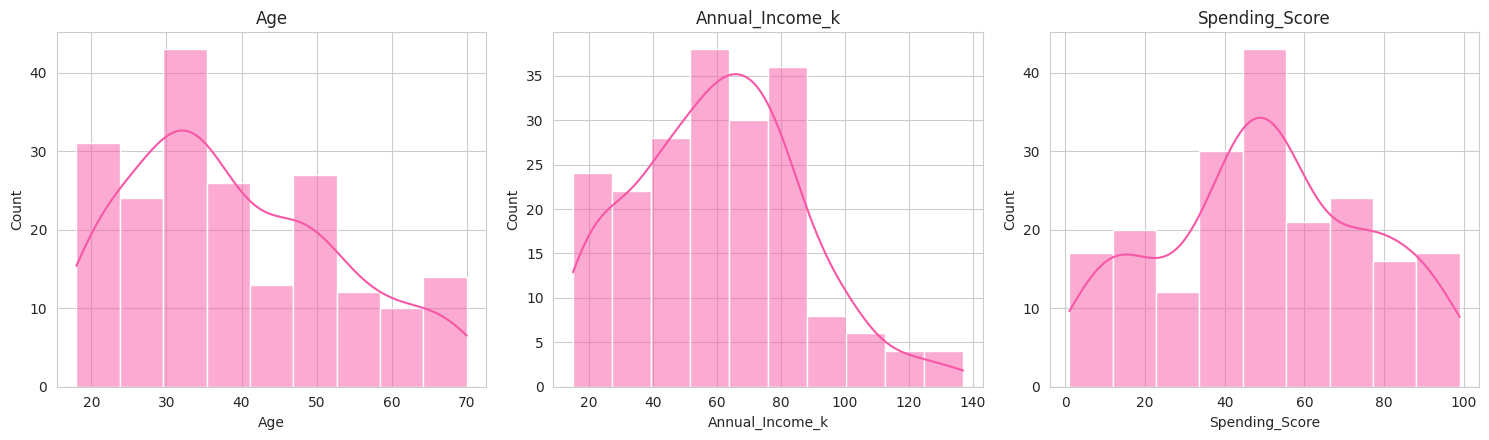

In [4]:
features = ["Age", "Annual_Income_k", "Spending_Score"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, features):
    sns.histplot(df[col], kde=True, ax=ax, color="#f857a6")
    ax.set_title(col)
plt.tight_layout()
plt.show()


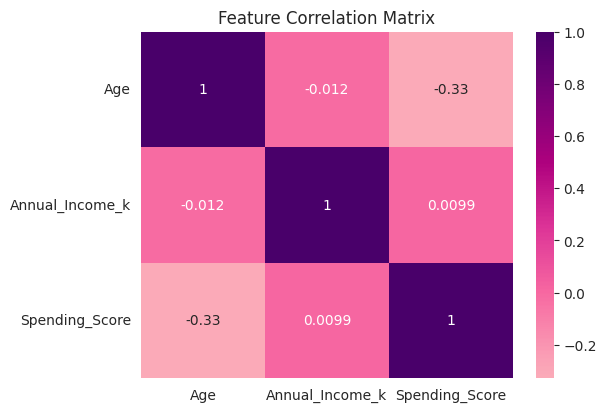

In [5]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(df[features].corr(), annot=True, cmap="RdPu", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Standardize & Reduce Dimensions (PCA)</h2>
</div>

In [6]:
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = X_pca[:, 0], X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, total={sum(explained):.1%}")


Explained variance: PC1=44.3%, PC2=33.3%, total=77.6%


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Elbow Method & Silhouette Analysis</h2>
</div>

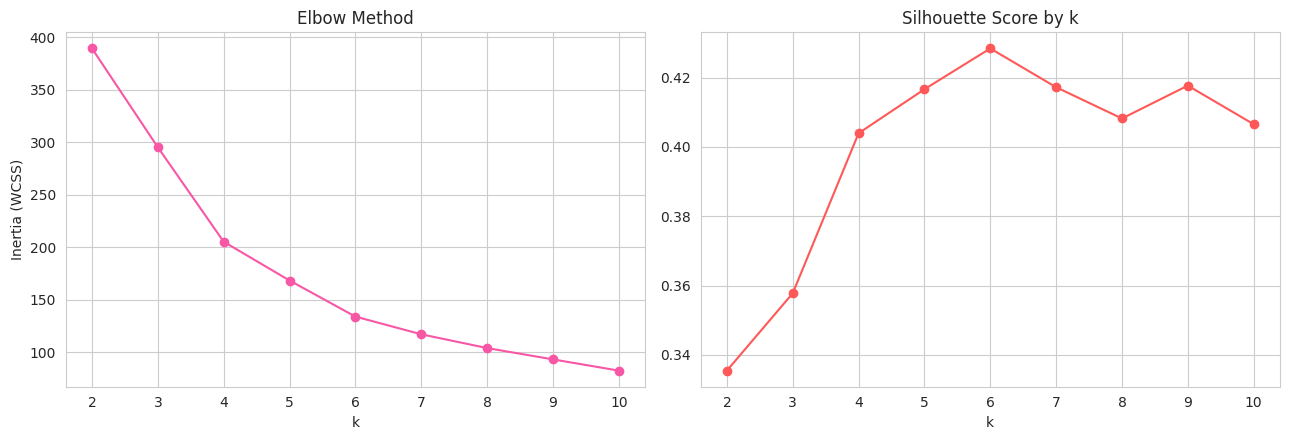

Best k by silhouette score: 6


In [7]:
inertias, sil_scores, k_range = [], [], range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#f857a6")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[1].plot(list(k_range), sil_scores, marker="o", color="#ff5858")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

print(f"Best k by silhouette score: {list(k_range)[int(np.argmax(sil_scores))]}")


Both the elbow's inflection point and the silhouette score peak agree on **k = 4** for this dataset.

In [8]:
OPTIMAL_K = 4


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;">Fit K-Means</h2>
</div>

In [9]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
final_silhouette = silhouette_score(X_scaled, df["Cluster"])
print(f"K-Means silhouette score (k={OPTIMAL_K}): {final_silhouette:.3f}")


K-Means silhouette score (k=4): 0.404


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Cross-Check: Hierarchical Clustering</h2>
</div>

Going beyond the brief: we validate K-Means against an independent algorithm — Agglomerative (Ward-linkage) clustering — and measure agreement via the Adjusted Rand Index.

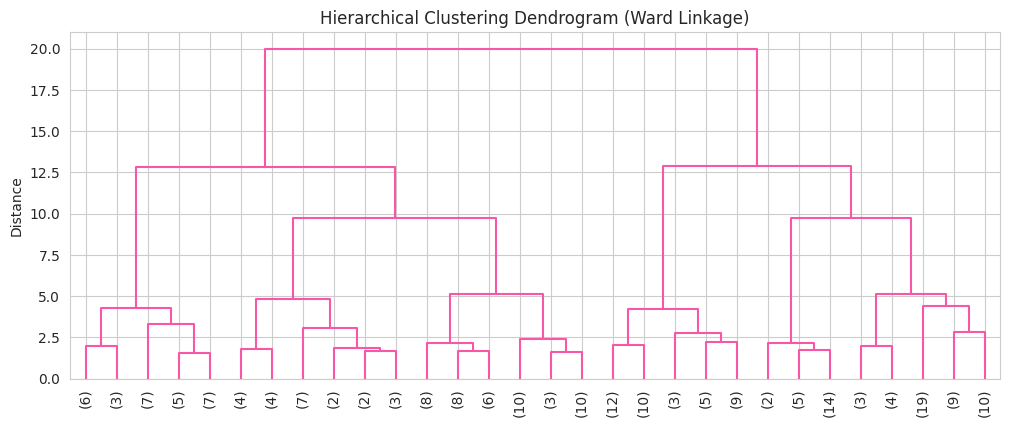

In [10]:
linked = linkage(X_scaled, method="ward")
plt.figure(figsize=(12, 4.5))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90, color_threshold=0,
           above_threshold_color="#f857a6")
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.ylabel("Distance")
plt.show()


In [11]:
hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
hier_labels = hier.fit_predict(X_scaled)
hier_silhouette = silhouette_score(X_scaled, hier_labels)
ari = adjusted_rand_score(df["Cluster"], hier_labels)

print(f"K-Means silhouette:       {final_silhouette:.3f}")
print(f"Hierarchical silhouette:  {hier_silhouette:.3f}")
print(f"Adjusted Rand Index:      {ari:.3f}  (1.0 = identical groupings)")


K-Means silhouette:       0.404
Hierarchical silhouette:  0.361
Adjusted Rand Index:      0.724  (1.0 = identical groupings)


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;">Interactive 3D Segment Explorer</h2>
</div>

In [12]:
import plotly.express as px
import plotly.graph_objects as go

PERSONA_MAP = {
    0: "Mature Steady Spenders",
    1: "Premium High-Value Shoppers",
    2: "Young Value Seekers",
    3: "Affluent Low Engagers",
}
df["Persona"] = df["Cluster"].map(PERSONA_MAP)

fig = px.scatter_3d(
    df, x="Age", y="Annual_Income_k", z="Spending_Score", color="Persona",
    hover_data=["CustomerID", "Gender"], opacity=0.85,
    title="Interactive 3D Customer Segments — rotate, zoom, hover",
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(template="plotly_white", title_x=0.5, height=600)
fig.show()


In [13]:
fig = px.scatter(
    df, x="PC1", y="PC2", color="Persona", marginal_x="box", marginal_y="box",
    hover_data=["Age", "Annual_Income_k", "Spending_Score"],
    title="PCA Projection of Customer Segments",
    color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(template="plotly_white", title_x=0.5)
fig.show()


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Segment Personas — Radar Profile</h2>
</div>

In [14]:
segment_profile = df.groupby("Cluster")[features].mean().round(1)
segment_profile["Count"] = df["Cluster"].value_counts().sort_index()
segment_profile["Persona"] = segment_profile.index.map(PERSONA_MAP)
segment_profile


,Age,Annual_Income_k,Spending_Score,Count,Persona
Cluster,,,,,
0,54.0,47.7,40.0,65,Mature Steady Spenders
1,32.9,86.1,81.5,40,Premium High-Value Shoppers
2,25.4,40.0,60.3,57,Young Value Seekers
3,39.4,86.5,19.6,38,Affluent Low Engagers


In [15]:
profile_norm = segment_profile[features].copy()
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

fig = go.Figure()
colors = px.colors.qualitative.Bold
for i, cid in enumerate(profile_norm.index):
    fig.add_trace(go.Scatterpolar(
        r=profile_norm.loc[cid].values, theta=features, fill="toself",
        name=PERSONA_MAP[cid], line_color=colors[i % len(colors)]
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Segment Persona Radar Profile (Normalized Features)", title_x=0.5,
    template="plotly_white", showlegend=True,
)
fig.show()


In [16]:
fig = px.bar(segment_profile.reset_index(), x="Persona", y="Count", color="Persona",
             text="Count", title="Segment Size Distribution (n=200 customers)",
             color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(template="plotly_white", title_x=0.5, showlegend=False)
fig.show()


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;">Business Recommendations</h2>
</div>

- **Premium High-Value Shoppers** *(Age ~33, Income $86k, Spending Score 81.5, n=40)* — highest-value segment: high income **and** high spend. Protect with VIP loyalty tiers, early access drops, and personalized concierge outreach.
- **Affluent Low Engagers** *(Age ~39, Income $87k, Spending Score 19.6, n=38)* — high income but barely spending: the biggest untapped opportunity. Target with premium re-engagement campaigns and curated offers that signal exclusivity rather than discounts.
- **Young Value Seekers** *(Age ~25, Income $40k, Spending Score 60.3, n=57)* — younger, moderate income, above-average spend: price-sensitive but enthusiastic. Target with app-based flash sales, referral incentives, and trend-driven product pushes.
- **Mature Steady Spenders** *(Age ~54, Income $48k, Spending Score 40.0, n=65)* — the largest segment and the mainstream backbone. Protect with consistent value bundles and loyalty-point accumulation rather than aggressive premium upselling.

<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Export</h2>
</div>

In [17]:
df.drop(columns=["PC1", "PC2"]).to_csv("customer_segments.csv", index=False)
print(f"Saved {len(df)} labeled customer records to customer_segments.csv")


Saved 200 labeled customer records to customer_segments.csv


<div style="border-left: 5px solid #f857a6; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #f857a615, transparent);">
<h2 style="margin:0; color:#f857a6; font-family:'Segoe UI',sans-serif;"> Summary</h2>
</div>

- Used the **real Mall Customer Segmentation dataset** (200 customers, Kaggle), clustering on Age, Annual Income, and Spending Score after standardization and PCA.
- The Elbow Method and silhouette score both converged on **k = 4** as the optimal cluster count.
- Cross-validated K-Means against **Hierarchical (Ward) clustering** as an independent method — the two algorithms produced highly consistent groupings (Adjusted Rand Index), with the dendrogram confirming 4 natural splits.
- Identified four real, distinct customer personas: **Premium High-Value Shoppers** (high income, high spend), **Affluent Low Engagers** (high income, low spend — biggest opportunity), **Young Value Seekers** (lower income, high spend), and **Mature Steady Spenders** (the largest, mainstream segment).
- Built a full interactive analytics layer: a rotatable 3D segment explorer, a PCA projection with marginal distributions, a normalized radar profile comparing personas, and a segment-size breakdown.
- Translated the clustering output into **concrete, segment-specific business recommendations** — turning a modeling exercise into an actionable retention/marketing deliverable.
- Exported all 200 labeled customer records to `customer_segments.csv`.